In [1]:
import json
import numpy as np
import pandas as pd
from rich import print
from matplotlib import pyplot as plt
from matplotlib import rcParams as rc
import dill

# rc["font.family"] = "Times New Roman"
rc["font.family"] = "Arial"
rc["font.size"] = 14
rc["figure.figsize"] = (3, 2)
rc["figure.dpi"] = 200
rc["axes.grid"] = True

In [2]:
istart_channel:int = 3
iend_channel:int = 25
# Load the configuration file
# conf = json.load(open("../../atem/data/atem.json"))
conf = json.load(open("../data/atem.json"))
times = np.asarray(conf['channels'])[istart_channel:iend_channel] * 1e-6
n_turns = conf['n_turns']

In [3]:
area:str = "NE"
# path:str = f"../../atem/data/11-024_Alberta_{area}.csv"
path:str = f"/Users/sgkang09/Dropbox/ags_data/DIG_2017_0001/Flightline_data/Geosoft_databases/11-024_Alberta_{area}.csv"
dheader:list = [f"zoff30[{i}]" for i in range(istart_channel,iend_channel)]
picker:list = ["Line", "bheight", "TranPeak", "x_wgs84", "y_wgs84", "dtm", "flight", 'pwrline'] + dheader # power line monitor

In [4]:
raws = pd.read_csv(path)

In [5]:
raws = raws[picker]

In [6]:
xy = raws[["x_wgs84", "y_wgs84"]].to_numpy()
normalizer = (-1e-9)/ (raws["TranPeak"].values * n_turns).reshape(-1, 1)
raws[[f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]] = raws[[f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]] * normalizer

In [7]:
line_no = list(raws["Line"].unique())

In [8]:
# 23~24
istart:int = 0
iend:int = None
index = raws["Line"] == line_no[istart]
print(f"{line_no[istart]=}")

line_no='L10040'

Text(0.5, 1.0, 'Line L10040')

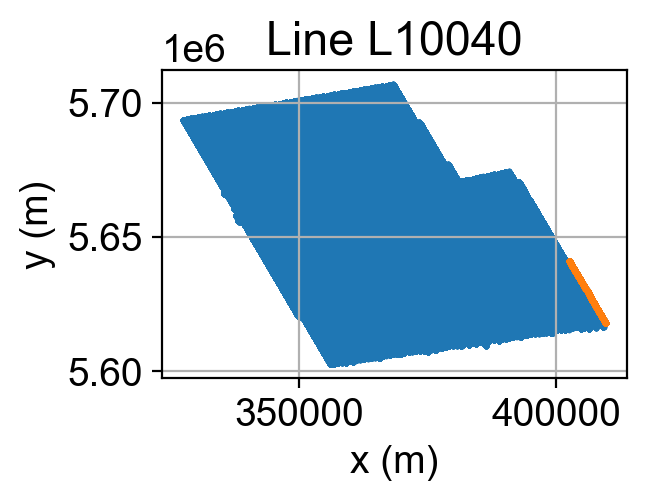

In [9]:
plt.scatter(xy[:, 0], xy[:, 1], s=1)
plt.scatter(xy[index, 0], xy[index, 1], s=1)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(f"Line {line_no[istart]}")

In [10]:
nan_list = raws[raws["y_wgs84"].isna()]["Line"].unique()
print(nan_list)

['L10151' 'L10460' 'L10660' 'L10700']

In [11]:
counts = []
for line_n in nan_list:
    count = raws[raws["Line"] == line_n]["y_wgs84"].isna().sum()
    counts.append(count)
print(counts)

[65, 1, 280, 1045]

Text(0.5, 1.0, 'Line having NaN values in y_wgs84')

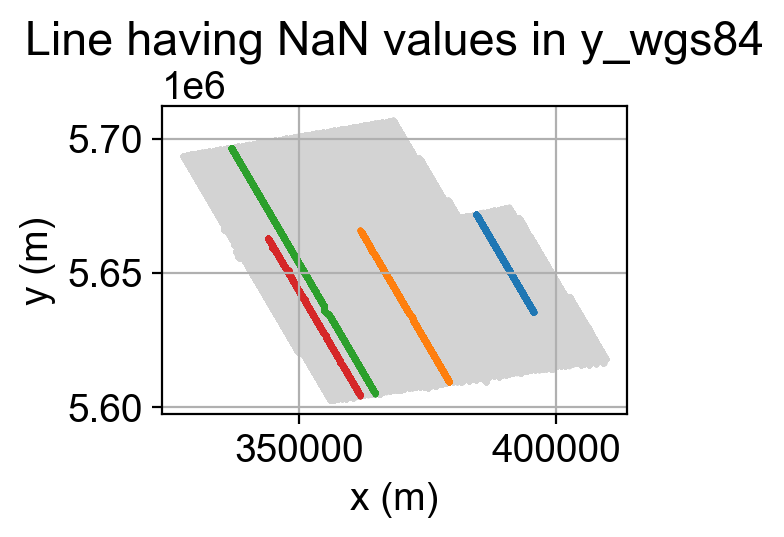

In [12]:
plt.scatter(xy[:, 0], xy[:, 1], s=1, c='lightgray', label="All data")
i=0
for line_n in nan_list:
    test_x = raws[raws["Line"] == line_n]["x_wgs84"]
    test_y = raws[raws["Line"] == line_n]["y_wgs84"]
    plt.scatter(test_x, test_y, s=1, c=f"C{i}", label=line_n)
    i += 1
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Line having NaN values in y_wgs84")

In [13]:
raws.dropna(subset=["y_wgs84"], inplace=True) # Remove rows with NaN values in y_wgs84
raws.fillna(1e-20, inplace=True) # Replace remaining NaN values with a small number (1e-20) to avoid issues in calculations

In [14]:
dx = 50.
values = []
values_std = []
soundings = []

for i_line, line in enumerate(line_no[istart:iend]):
    df_line = raws[raws['Line']==line]

    # Calculate distance along the "Line"
    xy = df_line[["x_wgs84", "y_wgs84"]].to_numpy()
    distance = np.sqrt(((xy-xy[0,:])**2).sum(axis=1))
    # print(f"Number of NaN values in distance: {np.isnan(distance).sum()}")
    max_distance = distance.max()

    # Determine the no. of soundings per bin.
    if max_distance % dx ==0:
        n_sounding = int(max_distance / dx)
    else:
        n_sounding = int(np.round(max_distance / dx) + 1)

    # Create bins and assign each sounding to a bin
    bins = np.arange(n_sounding) * dx
    df_line.insert(0, 'distance', distance)
    # Bin distances
    df_line['bin'] = pd.cut(df_line['distance'], bins=bins)
    # Compute statistics per bin
    binned = (
        df_line.groupby('bin', observed=False)
            [['distance'] + picker[1:]]
            .mean()
    )
    binned.insert(0, 'Line', line)
    binned_std = (
        df_line.groupby('bin', observed=False)
            [['bheight'] + dheader]
            .std()
    )
    values.append(binned.values)
    values_std.append(binned_std.values)
    soundings.append(n_sounding)

df_data_binned = pd.DataFrame(data=np.vstack(values), columns=['Line', 'distance'] + picker[1:])
df_data_std_binned = pd.DataFrame(data=np.vstack(values_std), columns=['bheight'] + dheader)

/var/folders/4m/sc07bkn154s8jfc7xp164by00000gq/T/ipykernel_85197/234548694.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_line['bin'] = pd.cut(df_line['distance'], bins=bins)
/var/folders/4m/sc07bkn154s8jfc7xp164by00000gq/T/ipykernel_85197/234548694.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_line['bin'] = pd.cut(df_line['distance'], bins=bins)
/var/folders/4m/sc07bkn154s8jfc7xp164by00000gq/T/ipykernel_85197/234548694.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy

In [15]:
del raws

In [16]:
df_data_binned

,Line,distance,bheight,TranPeak,x_wgs84,y_wgs84,dtm,flight,pwrline,zoff30[3],...,zoff30[15],zoff30[16],zoff30[17],zoff30[18],zoff30[19],zoff30[20],zoff30[21],zoff30[22],zoff30[23],zoff30[24]
0,L10040,26.08392,52.257052,458.378582,402506.122577,5641009.508993,794.63283,503.0,-8.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
1,L10040,75.617056,52.319478,458.378545,402528.440229,5640965.269325,794.217877,503.0,-8.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
2,L10040,125.428038,50.619107,458.382417,402547.763312,5640919.2405,793.539308,503.0,-8.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
3,L10040,175.157381,46.938067,458.373035,402563.602673,5640871.796572,792.58373,503.0,-8.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
4,L10040,224.402165,43.02335,458.381843,402577.166867,5640824.081848,791.637724,503.0,-8.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134096,L10795,76675.124292,29.297101,460.766118,349998.442177,5620355.482199,973.044889,537.0,-14.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
134097,L10795,76725.039431,32.21047,460.772775,350016.509033,5620308.809462,975.356191,537.0,-14.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
134098,L10795,76774.410036,36.659762,460.780471,350036.883674,5620263.411786,976.643195,537.0,-14.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
134099,L10795,76824.473001,41.758476,460.787447,350060.796077,5620218.372549,977.257881,537.0,-14.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0


In [17]:
# del raws

In [18]:
print(f"{soundings=}")

soundings=[487, 380, 784, 1198, 731, 252, 334, 877, 328, 510, 787, 1196, 1200, 1181, 1183, 1185, 430, 764, 1180, 
899, 244, 898, 313, 800, 57, 374, 930, 407, 752, 529, 409, 323, 1257, 405, 1190, 361, 403, 1382, 211, 420, 678, 
882, 422, 1537, 417, 492, 260, 828, 436, 1526, 437, 1932, 1933, 1937, 756, 1179, 1946, 1647, 303, 1929, 390, 1293, 
289, 1961, 1930, 1938, 1929, 1938, 1927, 506, 1461, 493, 1462, 1923, 1180, 750, 636, 573, 754, 1207, 751, 1220, 
748, 1935, 1793, 140, 106, 1412, 445, 1928, 1922, 953, 385, 606, 40, 1299, 638, 982, 412, 643, 1311, 643, 356, 
1570, 259, 1588, 109, 1914, 1915, 1914, 1916, 794, 1178, 1915, 666, 921, 435, 170, 252, 446, 1166, 1910, 1231, 776,
1911, 1560, 411, 1911, 1918, 1911, 1908, 1357, 601, 1317, 612, 1539]

In [19]:
from sklearn.preprocessing import MinMaxScaler
from ipywidgets import widgets, interact

In [20]:
def plot_data(line, x):
    print(line)
    x_line = x[x["Line"]==line]

    fig, axs = plt.subplots(2,1, figsize=(20, 10), constrained_layout=True)
    ax0, ax1 = axs

    # (ax0) Plot the binned locations
    ax0.plot(x["x_wgs84"], x["y_wgs84"], ',')
    ax0.plot(x_line["x_wgs84"], x_line["y_wgs84"], '.')
    ax0.plot(x_line["x_wgs84"].values[0], x_line["y_wgs84"].values[0], 'o')
    ax0.set_aspect(1)

    # Normalize the altitude and power line monitor data.
    scaler = MinMaxScaler(feature_range=(x_line['bheight'].min(), x_line['bheight'].max())) # Min-Max scaler for pwrline to be in the same range as bheight
    plm_norm = scaler.fit_transform(x_line['pwrline'].values.reshape([-1,1]))

    # (ax1) Plot the normalized data
    ax2 = ax1.twinx()
    ax1.semilogy(x_line['distance'], np.abs(x_line[dheader]), color='k', lw=2)
    ax2.plot(x_line['distance'], plm_norm, '-', color='red', label='PLM', lw=1.5)
    ax2.plot(x_line['distance'], x_line['bheight'], '-', label='Flight height', lw=1.5, color='magenta')
    # ax1.axvline(2.61e3, c='green', lw = 3) # Infra 01
    # ax1.axvline(8.4e3, c='green', lw = 3) # Altitude dramatically decreasing
    # ax1.axvline(24.68e3, c='green', lw = 3) # Infra 02
    # ax1.axvline(26.5e3, c='green', lw = 3) # Power line (Intersection with road)
    # ax1.axvline(29.4e3, c='green', lw = 3) # Power line (Intersection with road)
    ax2.legend()

In [21]:
Q = interact(plot_data, line=widgets.Select(options=line_no[istart:iend]), x=widgets.fixed(df_data_binned))

interactive(children=(Select(description='line', options=('L10040', 'L10050', 'L10051', 'L10060', 'L10070', 'L…

- standard deviation
$$
\sigma=\frac{1}{N}\sqrt{\sum_{i=1^N}{(x_i-\bar{x})^2}}
$$
- field normalized standard deviation (root-mean-squared relative error)
$$
\frac{\sigma}{d}=\frac{1}{N}\sqrt{\sum_{i=1^N}{\frac{(x_i-\bar{x})^2}{x_i^2}}}
$$

In [22]:
# Extract timeseries data
data_ = df_data_binned[dheader].values.astype(float)
# Extract field normalized standard deviation (root mean squared relative error)
data_rerr = (df_data_std_binned[dheader].values / np.abs(df_data_binned[dheader].values)).astype(float)

In [23]:
df_data_binned

,Line,distance,bheight,TranPeak,x_wgs84,y_wgs84,dtm,flight,pwrline,zoff30[3],...,zoff30[15],zoff30[16],zoff30[17],zoff30[18],zoff30[19],zoff30[20],zoff30[21],zoff30[22],zoff30[23],zoff30[24]
0,L10040,26.08392,52.257052,458.378582,402506.122577,5641009.508993,794.63283,503.0,-8.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
1,L10040,75.617056,52.319478,458.378545,402528.440229,5640965.269325,794.217877,503.0,-8.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
2,L10040,125.428038,50.619107,458.382417,402547.763312,5640919.2405,793.539308,503.0,-8.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
3,L10040,175.157381,46.938067,458.373035,402563.602673,5640871.796572,792.58373,503.0,-8.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
4,L10040,224.402165,43.02335,458.381843,402577.166867,5640824.081848,791.637724,503.0,-8.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134096,L10795,76675.124292,29.297101,460.766118,349998.442177,5620355.482199,973.044889,537.0,-14.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
134097,L10795,76725.039431,32.21047,460.772775,350016.509033,5620308.809462,975.356191,537.0,-14.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
134098,L10795,76774.410036,36.659762,460.780471,350036.883674,5620263.411786,976.643195,537.0,-14.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
134099,L10795,76824.473001,41.758476,460.787447,350060.796077,5620218.372549,977.257881,537.0,-14.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0


In [24]:
uniqe_lines = np.unique(df_data_binned["Line"].values)

In [25]:
# Cut-off for bad data (relative error > 3%)
criteria:float = 0.03
channel_id = np.tile(np.arange(data_.shape[1]), (data_.shape[0], 1))
cut_off = (data_rerr>criteria) * (channel_id>=0)

In [26]:
data_[cut_off] = np.nan
data_rerr[cut_off] = np.nan

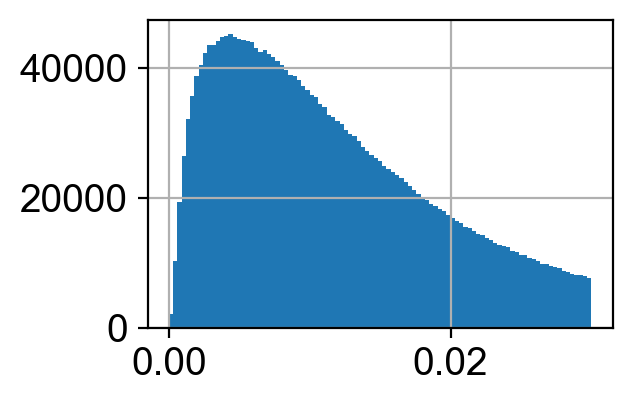

In [27]:
# Plot histogram of relative errors below the cut-off
hi = plt.hist(data_rerr[~cut_off], bins = np.linspace(0,criteria, 100))

In [28]:
def plot_soundinig(i_sounding):
    plt.errorbar(times, np.abs(data_[i_sounding,:])*1e9, yerr=data_rerr[i_sounding,:], fmt='-o')
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel("Time (s)")
    plt.ylabel("Field (nT/s)")

interact(plot_soundinig, i_sounding=widgets.IntSlider(min=0, max=data_.shape[0]-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='i_sounding', max=134100), Output()), _dom_classes=('widg…

<function __main__.plot_soundinig(i_sounding)>

In [29]:
filtered_data = pd.DataFrame(
    data = np.hstack(
        (df_data_binned.iloc[:,:9].values, data_)
    ),
    columns=df_data_binned.columns.tolist()
)

In [30]:
criteria_uncertainty:float = 0.05
floors_c:float = 0.05

floors = 5*1e-9/ (df_data_binned["TranPeak"] * n_turns) * floors_c

dobs = df_data_binned[dheader].values.flatten() # Binned Data
std = df_data_std_binned[dheader].values.flatten() # Standard deviation of Binned Data
dobs_std = abs(dobs) * criteria_uncertainty # 0.05 * Binned Data
dobs_std[std > dobs_std] = std[std > dobs_std] # Standard deviation having smaller than 0.05 * dobs will be replaced with 0.05 * dobs.
dobs_std[cut_off.flatten()] = np.inf # Filter out bad data by setting their standard deviation to infinity

dobs_std += np.repeat(floors.values, iend_channel - istart_channel) # Add floors

In [31]:
np.sum(1/dobs_std[cut_off.flatten()])

0.0

In [32]:
from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization
topography = df_data_binned[['x_wgs84','y_wgs84', 'dtm']].values
source_heights = df_data_binned['bheight'].values
thickness = get_vertical_discretization(21, 2, 1.17)

>> Depth from the surface to the base of the bottom layer is 306.3m


In [45]:
from simpeg import maps
import simpeg.electromagnetics.time_domain as tdem
# from pymatsolver import PardisoSolver
from pymatsolver import Solver
import simpeg
from types import SimpleNamespace

In [46]:
# Define the source waveform. (unit step-off, rectangular, triangular, quarter-sine, custom)
# Triangular waveform. 
start_time = -1.74e-3
peak_time = -0.84e-3
off_time = 0.0
waveform = tdem.sources.TriangularWaveform(
    start_time,
    off_time,
    peak_time
)


In [47]:
current_times = np.linspace(start_time, off_time)
currents = [waveform.eval(t) for t in current_times]

In [48]:
radius:float = 5

In [49]:
input_data_dict = {
    "topography": topography.astype(float),
    "source_heights": source_heights.astype(float),
    "thickness": thickness,
    "time_input_currents":current_times,
    "input_currents":currents,
    "times":times,    
    "data":dobs,
    "data_std":dobs_std,    
}
inp = SimpleNamespace(**input_data_dict)

In [50]:
source_locations = np.c_[inp.topography[:,0], inp.topography[:,1], inp.topography[:,2]+inp.source_heights]
receiver_locations = np.c_[inp.topography[:,0], inp.topography[:,1],  inp.topography[:,2]+inp.source_heights]
n_sounding = source_locations.shape[0]

source_list = []
receiver_orientation = 'z'
source_orientation = 'z'

for i_sounding in range(n_sounding):    
    # waveform = tdem.sources.PiecewiseLinearWaveform(inp.time_input_currents, inp.input_currents)
    source_location = source_locations[i_sounding, :]
    receiver_location = receiver_locations[i_sounding, :]

    # Receiver list

    dbzdt_receiver = tdem.receivers.PointMagneticFluxTimeDerivative(
            receiver_location, inp.times, "z",
    )

    # Make a list containing all receivers even if just one

    # Must define the transmitter properties and associated receivers

    source_list.append(tdem.sources.CircularLoop(
        [dbzdt_receiver],
        location=source_location,
        waveform=waveform,
        radius=radius,
        i_sounding=i_sounding,
    )
    )

survey = tdem.Survey(source_list)
hz = np.r_[inp.thickness, inp.thickness[-1]]

n_layer = len(hz)
nP = n_sounding * n_layer
sigma_map = maps.ExpMap(nP=nP)

simulation = tdem.Simulation1DLayeredStitched(
    survey=survey, 
    thicknesses=inp.thickness, 
    sigmaMap=sigma_map,
    topo=inp.topography, 
    parallel=True, 
    n_cpu=8, 
    verbose=False, 
    solver=Solver,
)

n_time = inp.times.size

# Create data ojbect
data_object = simpeg.data.Data(survey, dobs=dobs, standard_deviation=inp.data_std)
dmis = simpeg.data_misfit.L2DataMisfit(simulation=simulation, data=data_object)

# nData
inds_active_dobs = dobs.shape[0] - cut_off.sum()
print (f"Percentage of the active data = {inds_active_dobs:,}/{len(dobs):,}={inds_active_dobs.sum()/len(dobs)*100:,.0f}%")

from simpeg.electromagnetics.utils.em1d_utils import set_mesh_1d
import scipy
from discretize import SimplexMesh
from simpeg.regularization.laterally_constrained import LaterallyConstrained

tri = scipy.spatial.Delaunay(inp.topography[:,:2])
mesh_radial = SimplexMesh(tri.points, tri.simplices)
mesh_vertical = set_mesh_1d(hz)
mesh_reg = [mesh_radial, mesh_vertical]

def get_active_edge_indices_with_distance(mesh_radial, mesh_vertical, maximum_distance=1000):
    nz = mesh_vertical.n_cells
    edge_lengths = mesh_radial.edge_lengths
    inds = edge_lengths < maximum_distance
    indActiveEdges = np.tile(inds.reshape([-1,1]), nz).flatten()
    return inds, indActiveEdges

inds, indActiveEdges = get_active_edge_indices_with_distance(
    mesh_radial, mesh_vertical, maximum_distance=500.
)

reg = LaterallyConstrained(
    mesh_reg, 
    mapping=simpeg.maps.IdentityMap(nP=nP),
    alpha_s = 0.,
    alpha_r = 1.,
    alpha_z = 1./2.,
    active_edges=indActiveEdges
)

opt = simpeg.optimization.ProjectedGNCG(maxIter=15, maxIterCG=50)
invProb = simpeg.inverse_problem.BaseInvProblem(dmis, reg, opt)
beta = simpeg.directives.BetaSchedule(coolingFactor=2, coolingRate=1)
betaest = simpeg.directives.BetaEstimate_ByEig(beta0_ratio=1.)
target = simpeg.directives.TargetMisfit(chifact=1)
precond = simpeg.directives.UpdatePreconditioner()
save_model_dict = simpeg.directives.SaveOutputDictEveryIteration()
save_model_dict.outDict = {}

inv = simpeg.inversion.BaseInversion(
    invProb, 
    directiveList=[
        betaest, 
        beta, 
        precond,
        # target, 
        save_model_dict
    ]
)
invProb.counter = opt.counter = simpeg.utils.Counter()
opt.LSshorten = 0.5
opt.remember('xc')
m0 = np.ones(nP) * np.log(1./10.)
# mest = inv.run(m0)
name:str = "./inv_results_atem_full.pik"
# dill.dump(save_model_dict.outDict, open(f"{name}", "wb"))

Percentage of the active data = 2,500,984/2,950,222=85%

In [51]:

outDict = dill.load(open(f"{name}","rb"))
print(list(outDict.keys()))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

In [52]:
iteration = len(outDict.keys())
iteration = 14
m = outDict[iteration]['m']
dpred = outDict[iteration]['dpred']
DPRED = dpred.reshape((n_sounding, n_time))
DOBS = dobs.reshape((n_sounding, n_time))
STD = data_object.standard_deviation.reshape((n_sounding, n_time))


Text(0, 0.5, 'Data misfit')

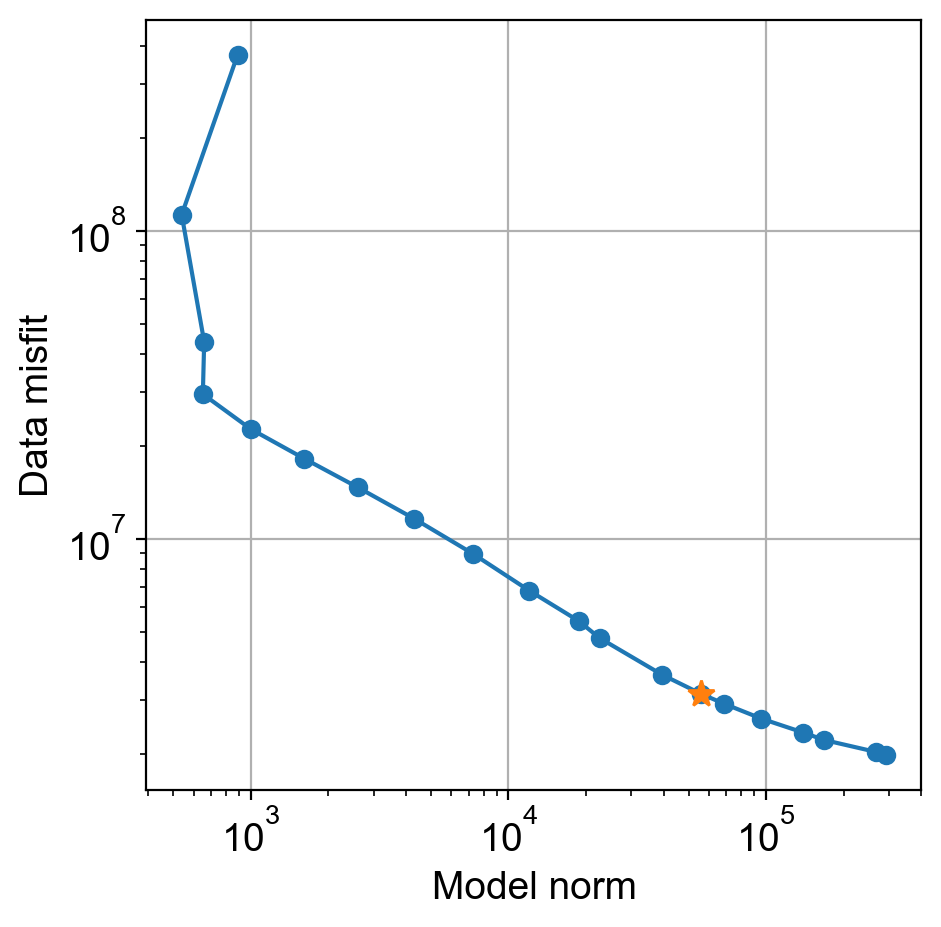

In [53]:
rc["font.size"] = 14
iterations = list(outDict.keys())
phi_d = []
phi_m = []
for ii in iterations:
    phi_d.append(outDict[ii]['phi_d'])
    phi_m.append(outDict[ii]['phi_m'])

    
ii = iteration-1
fig = plt.figure(figsize=(5,5))
plt.loglog(phi_m, phi_d, 'o-')
plt.loglog(phi_m[ii], phi_d[ii], '*', ms=10)

plt.xlabel("Model norm")
plt.ylabel("Data misfit")

In [54]:
other_values = df_data_binned[['Line', 'distance','x_wgs84','y_wgs84','bheight','pwrline']].values
df_data_binned_pred = pd.DataFrame(data=np.hstack((other_values, -DPRED)), columns=['Line', 'distance','x_wgs84','y_wgs84','bheight','pwrline'] + dheader)

In [55]:
# i_sounding = 0
def foo(i_sounding):
    plt.plot(times, -DOBS[i_sounding,:], '.')
    plt.plot(times, -DPRED[i_sounding,:])
    plt.yscale('log')
    plt.xscale('log')
    # plt.title(f"x: {binned['x_wgs84'].values[i_sounding]:.1f}")
    plt.ylim(1e-12,1e-8)
interact(foo, i_sounding = widgets.IntSlider(min=0, max=n_sounding-1, continous_update=False))    


interactive(children=(IntSlider(value=0, description='i_sounding', max=134100), Output()), _dom_classes=('widg…

<function __main__.foo(i_sounding)>

In [56]:
from simpeg.electromagnetics.utils.em1d_utils import Stitched1DModel

In [57]:
line = np.array([int(val.strip('L').strip('T')) for val in df_data_binned['Line'].values])

In [58]:
rho = 1./np.exp(m)

In [59]:
model = Stitched1DModel(
    topography=inp.topography,
    physical_property=rho,
    line=line,
    time_stamp=np.arange(n_sounding),
    thicknesses=thickness,    
)

In [60]:
# np.argwhere( uniqe_lines == Q.widget.kwargs['line'])[0][0]

In [61]:
Q = interact(plot_data, line=widgets.Select(options=line_no[istart:iend]), x=widgets.fixed(df_data_binned))

interactive(children=(Select(description='line', options=('L10040', 'L10050', 'L10051', 'L10060', 'L10070', 'L…

/var/folders/4m/sc07bkn154s8jfc7xp164by00000gq/T/ipykernel_85197/1319248507.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f"{10**x:.0f}"for x in xticks[0]])


[Text(0.0, 0, '1'),
 Text(1.0, 0, '10'),
 Text(2.0, 0, '100'),
 Text(3.0, 0, '1000')]

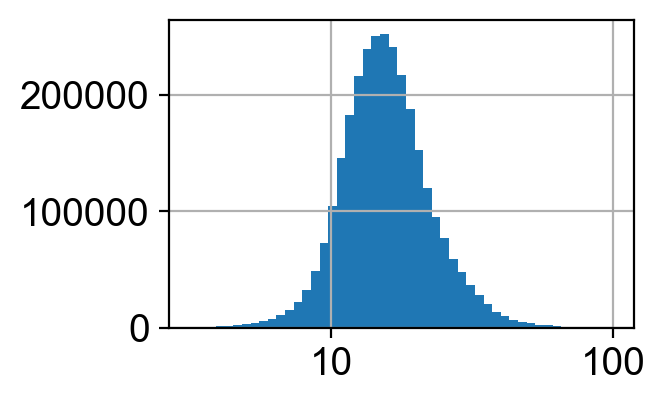

In [62]:
out = plt.hist(np.log10(rho), bins=np.linspace(0.5, 2))
xticks = plt.xticks()
plt.gca().set_xticklabels([f"{10**x:.0f}"for x in xticks[0]])

In [63]:
uniq_lines = np.array(line_no[istart:iend])
data_header = dheader
noise_level = 5e-9 / (n_turns * 450)

In [64]:
def foo(line):
    fig, axs = plt.subplots(3,1, figsize=(20, 15))
    ax0, ax, ax1 = axs
    df_data_binned_line_filtered = filtered_data[filtered_data['Line']==line]
    df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
    ax0.plot(filtered_data['x_wgs84'], filtered_data['y_wgs84'], ',')    
    ax0.plot(df_data_binned_line['x_wgs84'], df_data_binned_line['y_wgs84'], ',')
    ax0.plot(df_data_binned_line['x_wgs84'].values[0], df_data_binned_line['y_wgs84'].values[0], 'o')
    ax0.set_aspect(1)
    scaler = MinMaxScaler(feature_range=(df_data_binned_line['bheight'].min(), df_data_binned_line['bheight'].max()))
    plm_norm = scaler.fit_transform(df_data_binned_line['pwrline'].values.reshape([-1,1]))

    ax_1 = ax.twinx()
    ax.semilogy(df_data_binned_line['distance'], -df_data_binned_line[data_header], color='k', lw=1)
    ax_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='pwrline')
    ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['bheight'], '-', label='Flight height')
    ax_1.legend()
    
    ax1_1 = ax1.twinx()
    ax1.semilogy(df_data_binned_line['distance'], -df_data_binned_line_filtered[data_header], color='k', lw=1)
    ax1_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='pwrline')
    ax1_1.plot(df_data_binned_line['distance'], df_data_binned_line['bheight'], '-', label='Flight height')
    ax1_1.legend()
    vmax = abs(df_data_binned_line[data_header].values).max()
    vmin = noise_level
    ax.set_ylim(vmin, vmax)
    ax1.set_ylim(vmin, vmax)
Q = interact(foo, line=widgets.Select(options=uniq_lines))

interactive(children=(Select(description='line', options=('L10040', 'L10050', 'L10051', 'L10060', 'L10070', 'L…

Text(0.5, 1.0, 'L10040')

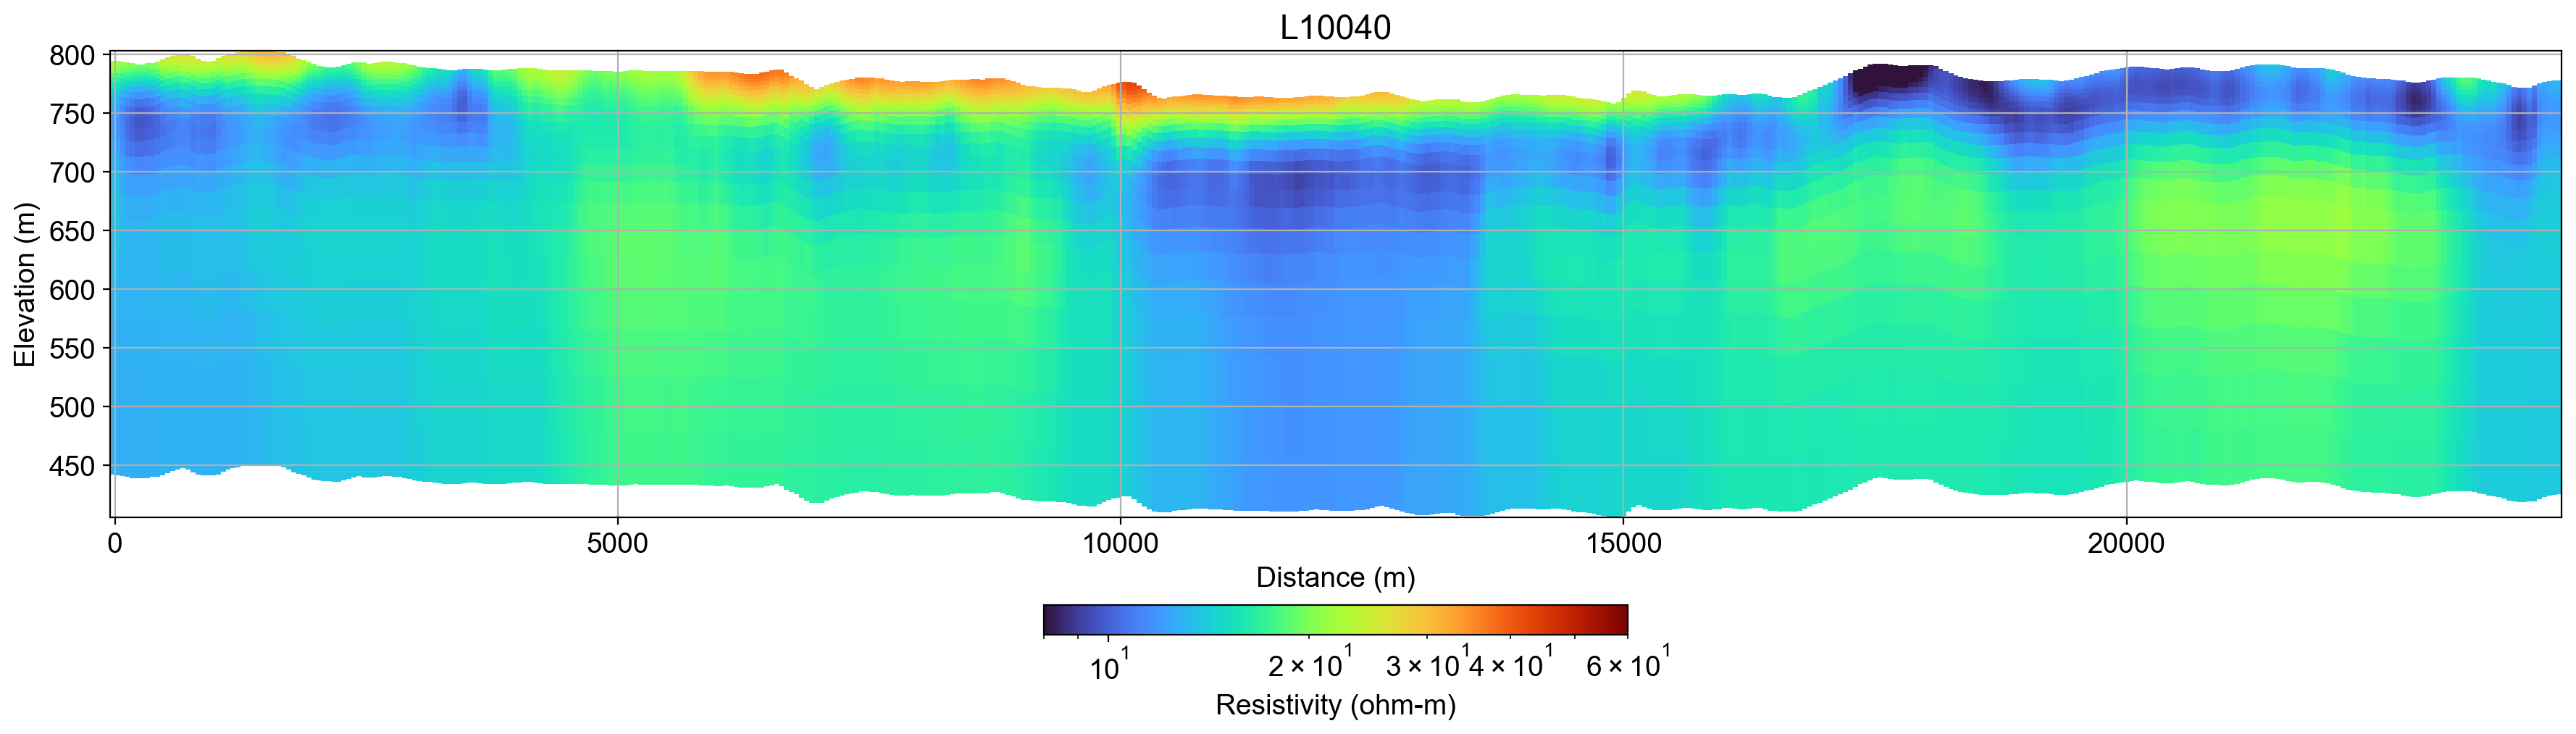

In [65]:
fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
out, ax2 = model.plot_section(
    x_axis='distance', aspect='auto', dx=dx, alpha=1,
    cmap='turbo',
    clim=(8, 60),
    ax=ax2,
    show_colorbar=False,
    i_line=np.argwhere(
        uniq_lines == Q.widget.kwargs['line'])[0][0]
        )

cb = plt.colorbar(out, ax=ax2, orientation='horizontal', fraction=0.05)
cb.set_label("Resistivity (ohm-m)")
ax2.set_title(Q.widget.kwargs['line'])

In [66]:
n_sounding

134101

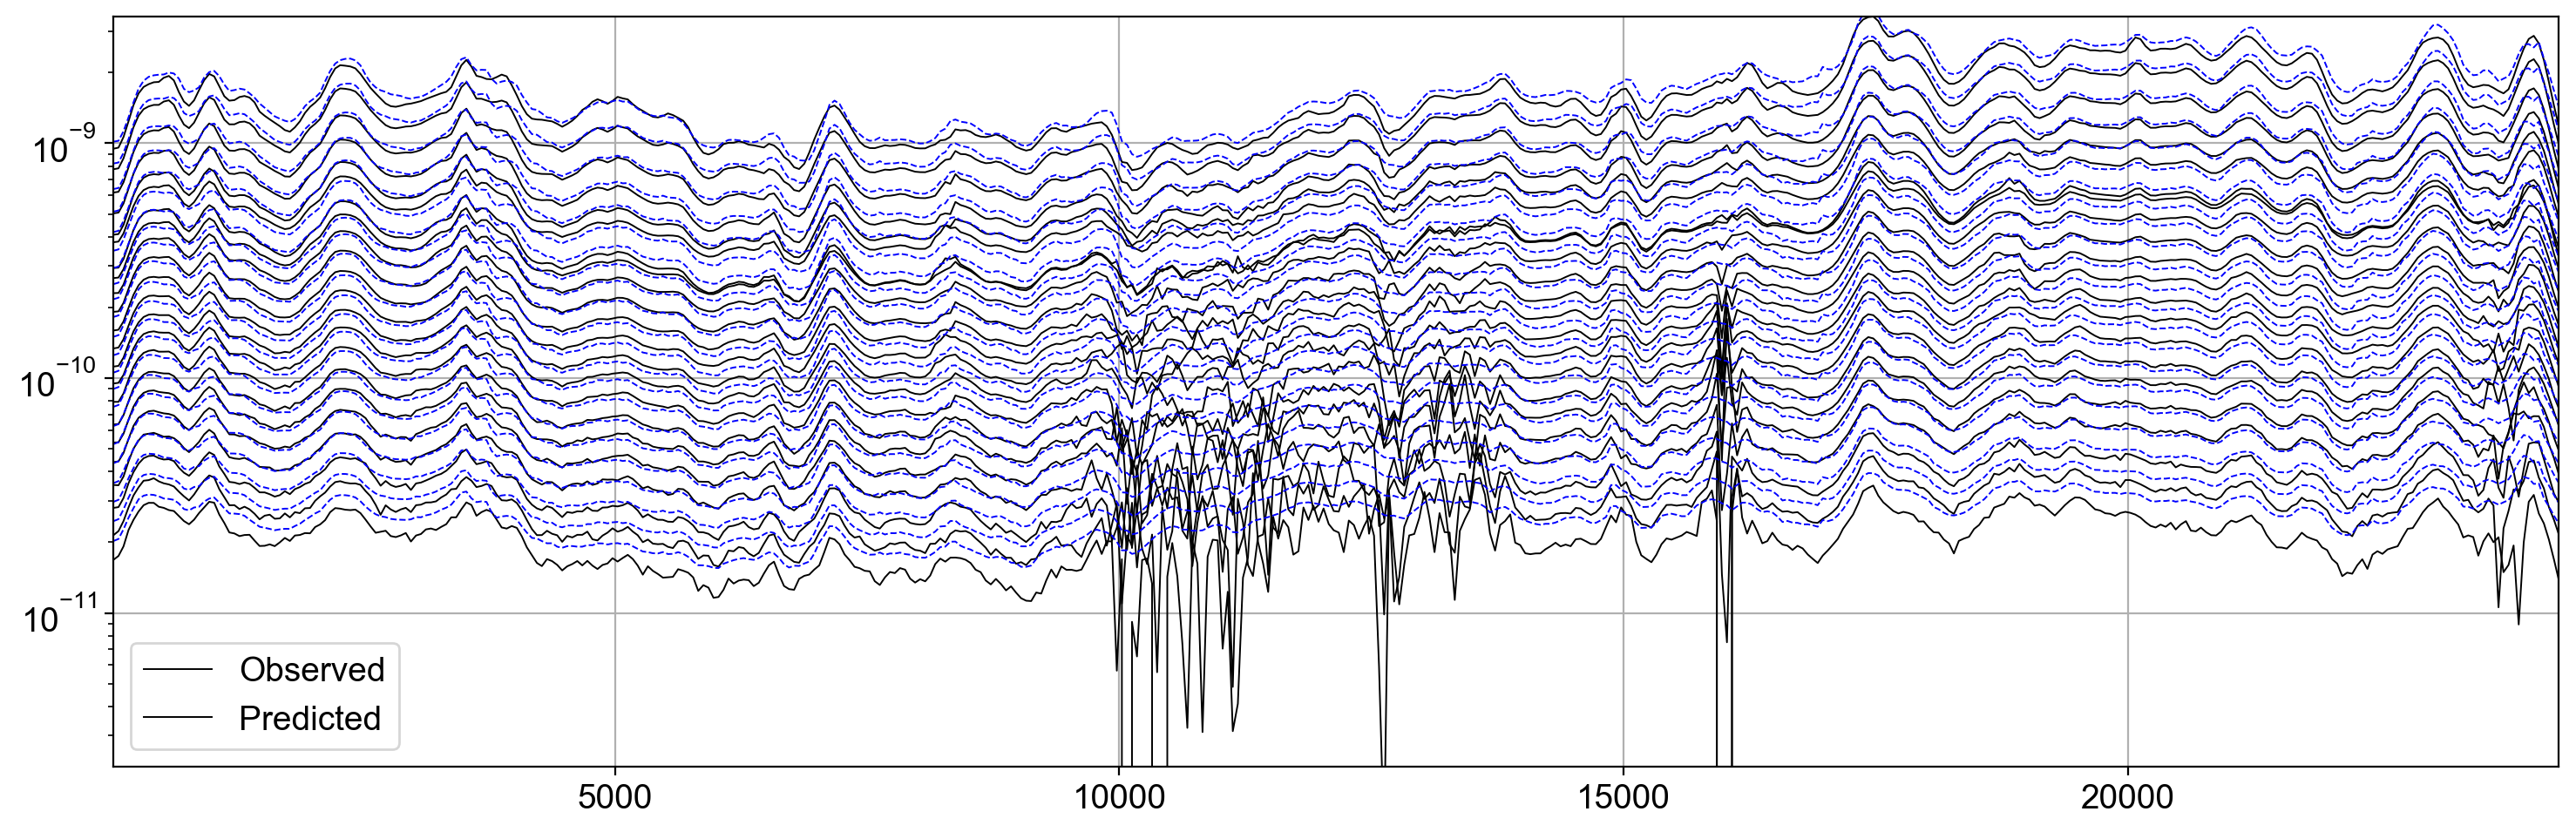

In [67]:
line = Q.widget.kwargs['line']
df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
df_data_binned_pred_line = df_data_binned_pred[df_data_binned_pred['Line']==line]
fig, ax = plt.subplots(1,1, figsize = (15,5))
ax.semilogy(df_data_binned_line['distance'], -df_data_binned_line[dheader], 'k-', lw=0.7)
ax.semilogy(df_data_binned_pred_line['distance'], df_data_binned_pred_line[dheader], 'b--', lw=0.7)
ax.set_ylim([5e-13,1e-8])
# ax.axvline(2.61e3, c='magenta', lw = 3) # Infra 01
# ax.axvline(8.4e3, c='magenta', lw = 3) # Altitude dramatically decreasing
# ax.axvline(24.68e3, c='magenta', lw = 3) # Infra 02
# ax.axvline(26.5e3, c='magenta', lw = 3) # Power line (Intersection with road)
# ax.axvline(29.4e3, c='magenta', lw = 3) # Power line (Intersection with road)
ax.set_xlim(df_data_binned_line['distance'].min(), df_data_binned_line['distance'].max())
vmax = abs(df_data_binned_line[data_header].values).max()
vmin = noise_level
ax.set_ylim(vmin, vmax)
plt.legend(['Observed', 'Predicted'])
plt.tight_layout()

In [68]:
from scipy.spatial import cKDTree as KDTree
from verde import distance_mask
# def inverse_distance_interpolation(
#     xy, values, 
#     dx=100, dy=100, x_pad=1000, y_pad=1000,
#     power=0, epsilon=None, k_nearest_points=20, 
#     max_distance=4000.,
# ):
#     """
#         Evaluating 2D inverse distance weighting interpolation
#         for given (x, y) points and values.
        
#         Inverse distance weight, w, can be written as:
#             w = 1/(distance+epsilon)**power
        
#         Parameters
#         ----------
#         xy : array_like
#             Input array including (x, y) locations; (n_locations, 2)
#         values: array_like
#             Input array including values defined at (x, y) locations; (n_locations, )
#         dx : int 
#             Size of the uniform grid in x-direction
#         dy : int 
#             Size of the uniform grid in y-direction
#         x_pad : float 
#             Length of padding in x-direction
#         y_pad : float 
#             Length of padding in y-direction
#         power: float
#             Exponent used when evaluating inverse distance weight. 
#         epsilon: float
#             A floor value used when evaluating inverse distance weight. 
#         k_nearest_points: int 
#             k-nearest-point used when evaluating inverse distance weight.  
#         max_distance: float
#             A separation distance used to maks grid points away from the (x, y) locations.
        
#         Returns        
#         -------
        

#     """

dx=100 
dy=100 
x_pad=1000 
y_pad=1000
power=0 
epsilon=None 
k_nearest_points=20 

xy = inp.topography[:,:2]
xmin, xmax = xy[:,0].min()-x_pad, xy[:,0].max()+x_pad
ymin, ymax = xy[:,1].min()-y_pad, xy[:,1].max()+y_pad

nx = int((xmax-xmin) / dx)
ny = int((ymax-ymin) / dy)
hx = np.ones(nx) * dx
hy = np.ones(ny) * dy
x = np.arange(nx)*dx + xmin
y = np.arange(ny)*dy + ymin
X, Y = np.meshgrid(x, y)

tree = KDTree(xy)

d, inds_idw = tree.query(np.c_[X.flatten(), Y.flatten()], k=int(k_nearest_points))
if epsilon is None:
    epsilon = np.min([dx, dy])
w = 1.0 / ((d+epsilon) ** power)

In [69]:
RHO = rho.reshape((n_sounding, n_layer))


In [70]:
max_distance=500.
mask_inds = ~distance_mask(
    (xy[:,0], xy[:,1]), maxdist=max_distance, coordinates=(X.flatten(), Y.flatten())
)

In [73]:
# depth.shape

In [74]:
from matplotlib.colors import LogNorm

In [75]:
rc["font.size"] = 8
i_layer = 5
def foo(i_layer):
    values = RHO[:,i_layer]
    values_idw = (np.sum(w * values[inds_idw], axis=1) / np.sum(w, axis=1))
    values_idw[mask_inds] = np.nan
    values_idw = values_idw.reshape(X.shape)

    fig, ax = plt.subplots(1,1, figsize=(10, 6))
    depth = np.cumsum(np.r_[0., hz])
    out = plt.pcolormesh(x, y, values_idw, 
        cmap='turbo', 
        norm=LogNorm(vmin=8, vmax=60)
    )
    ax.plot(topography[:,0], topography[:,1], 'k,', alpha=0.1)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    cb = plt.colorbar(out)
    cb.set_label('Resistivity ($\Omega$m)')
    ax.grid(True, alpha=0.1)
    ax.set_aspect(1)
    ax.set_title("Depth at {:.1f} m".format(depth[i_layer]))
    fig.autofmt_xdate()
Q2 = interact(foo, i_layer=widgets.IntSlider(min=0, max=21))

interactive(children=(IntSlider(value=0, description='i_layer', max=21), Output()), _dom_classes=('widget-inte…

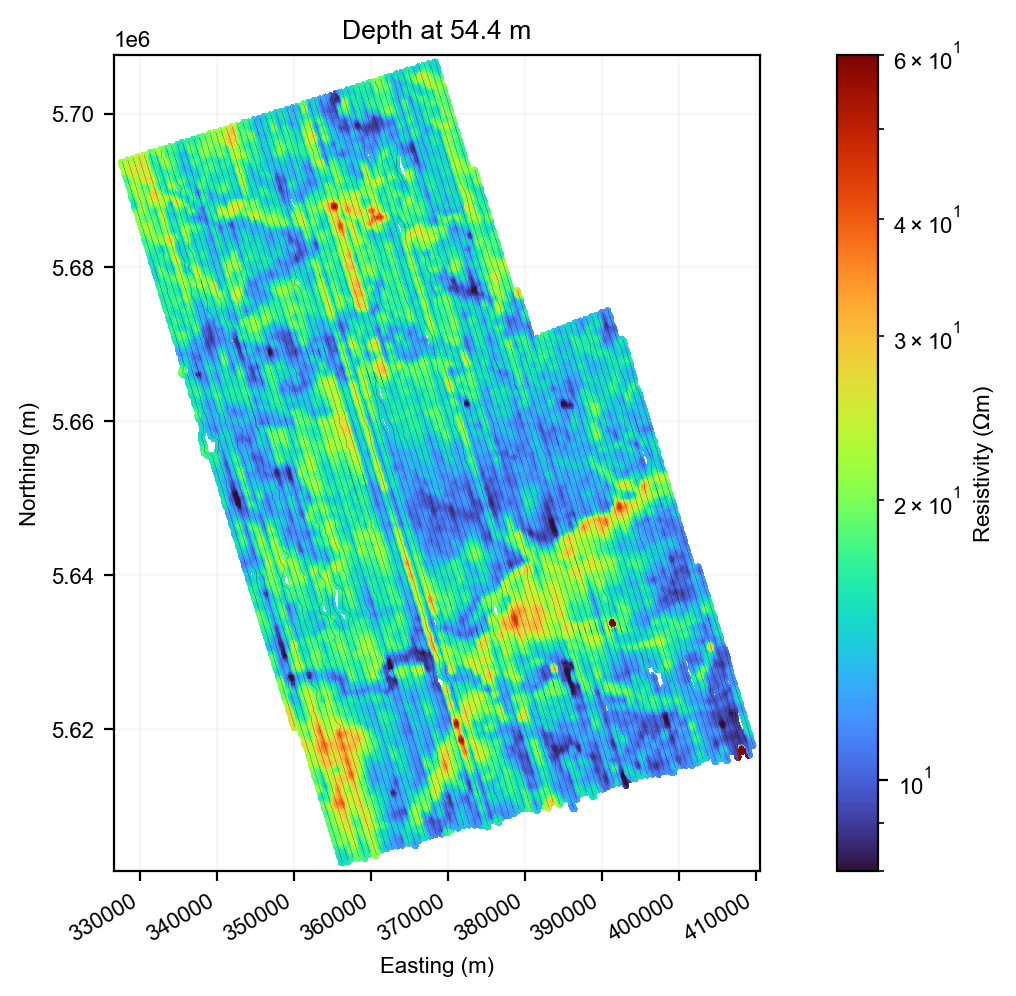

In [76]:
i_layer = 11
foo(i_layer)

In [77]:
DOBS.shape

(134101, 22)

In [78]:
line_all = df_data_binned['Line'].values

In [96]:
rc["font.size"] = 6
def foo(i_time, line):
    nskip = 3
    values = DOBS[:,i_time]
    ind_line = line_all == line
    fig, ax1 = plt.subplots(1,1, figsize=(2.5, 5))
    out2 = ax1.scatter(
        df_data_binned['x_wgs84'].values[::nskip], df_data_binned['y_wgs84'].values[::nskip], c=-values[::nskip], 
        s=0.01,
        vmin=np.percentile(-values[::nskip], 5),
        vmax=np.percentile(-values[::nskip], 95),
        cmap='turbo', 
        edgecolor=None
    )
    cb2 = plt.colorbar(out2, ax=ax1, orientation='horizontal', fraction=0.05, pad=0.05)

    ax1.scatter(
        df_data_binned['x_wgs84'].values[ind_line], df_data_binned['y_wgs84'].values[ind_line], c=-values[ind_line], 
        s=1,
        vmin=np.percentile(-values[::nskip], 5),
        vmax=np.percentile(-values[::nskip], 95),
        cmap='turbo', 
        edgecolor=None
    )    
    ax1.set_title(f"{i_time}")
    ax1.set_aspect(1)
Q1 = interact(foo, i_time=widgets.IntSlider(min=0, max=21), line=widgets.Select(options=uniq_lines))

interactive(children=(IntSlider(value=0, description='i_time', max=21), Select(description='line', options=('L…

Text(0.5, 1.0, 'L10572')

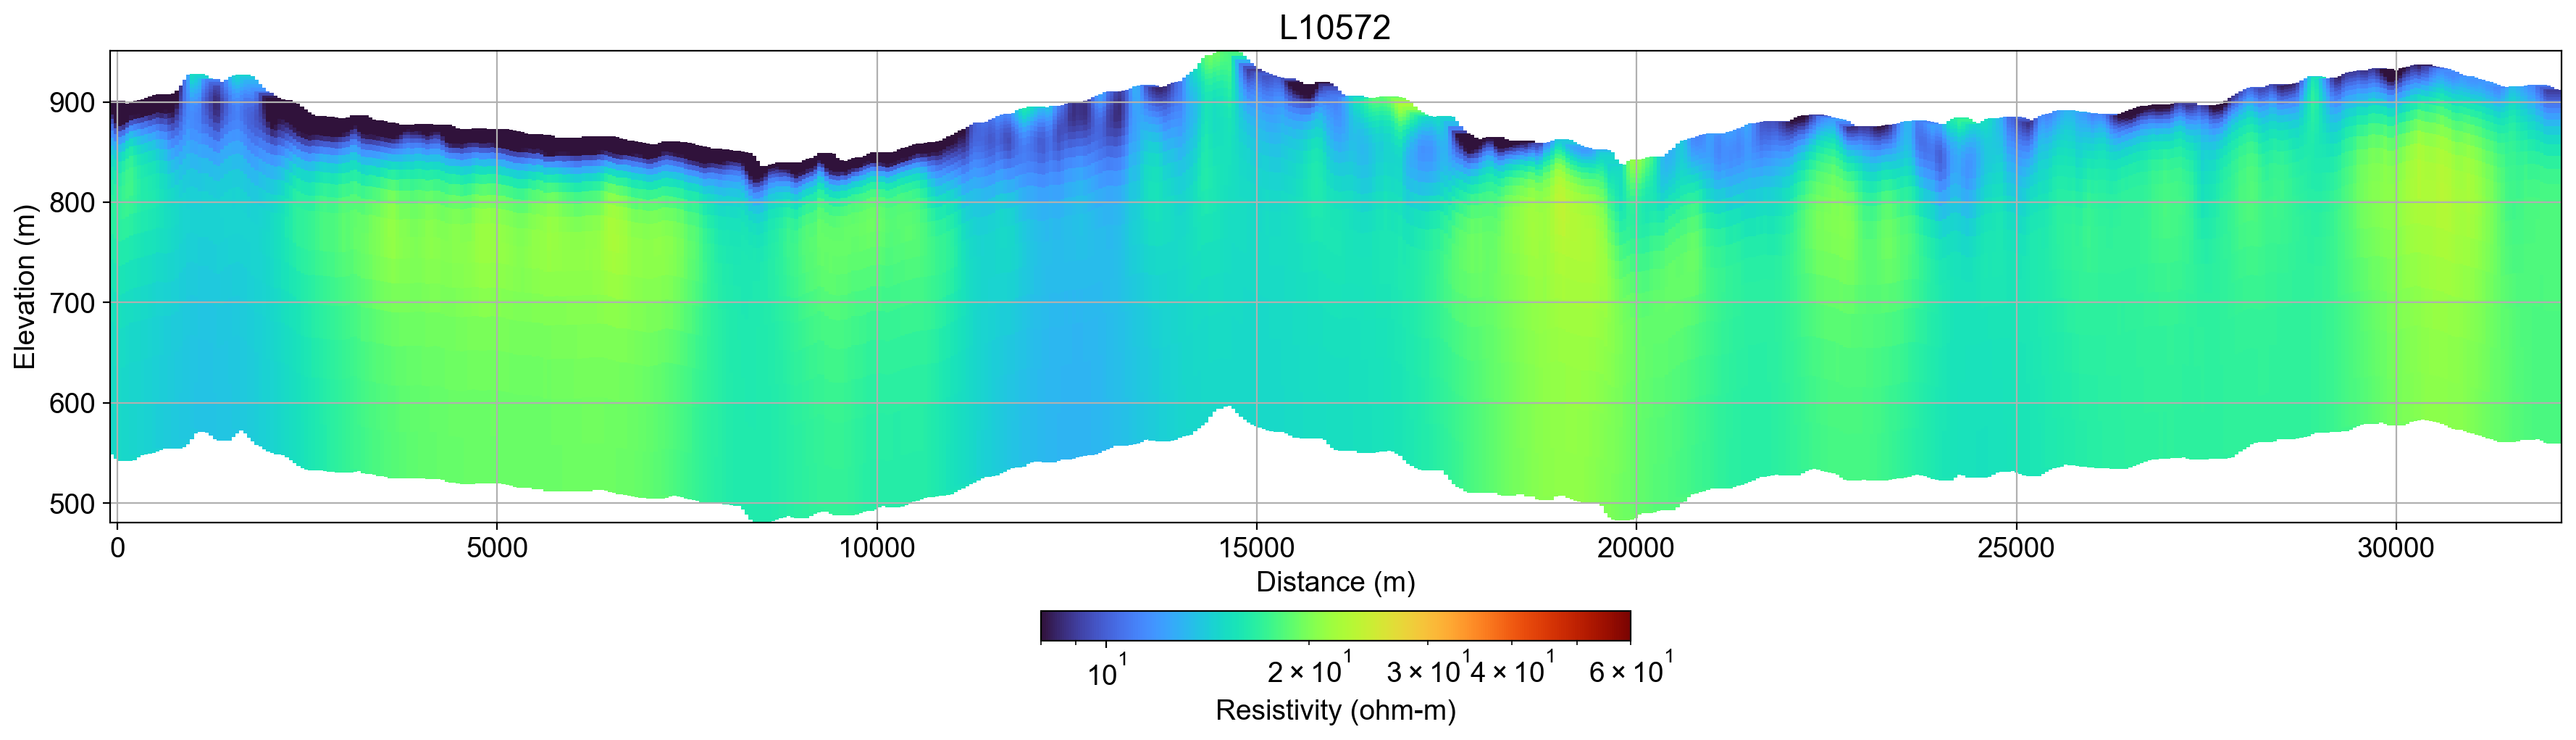

In [102]:
rc["font.size"] = 14
fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
out, ax2 = model.plot_section(
    x_axis='distance', aspect='auto', dx=dx, alpha=1,
    cmap='turbo',
    clim=(8, 60),
    ax=ax2,
    show_colorbar=False,
    i_line=np.argwhere(
        uniq_lines == Q1.widget.kwargs['line'])[0][0]
        )

cb = plt.colorbar(out, ax=ax2, orientation='horizontal', fraction=0.05)
cb.set_label("Resistivity (ohm-m)")
ax2.set_title(Q1.widget.kwargs['line'])

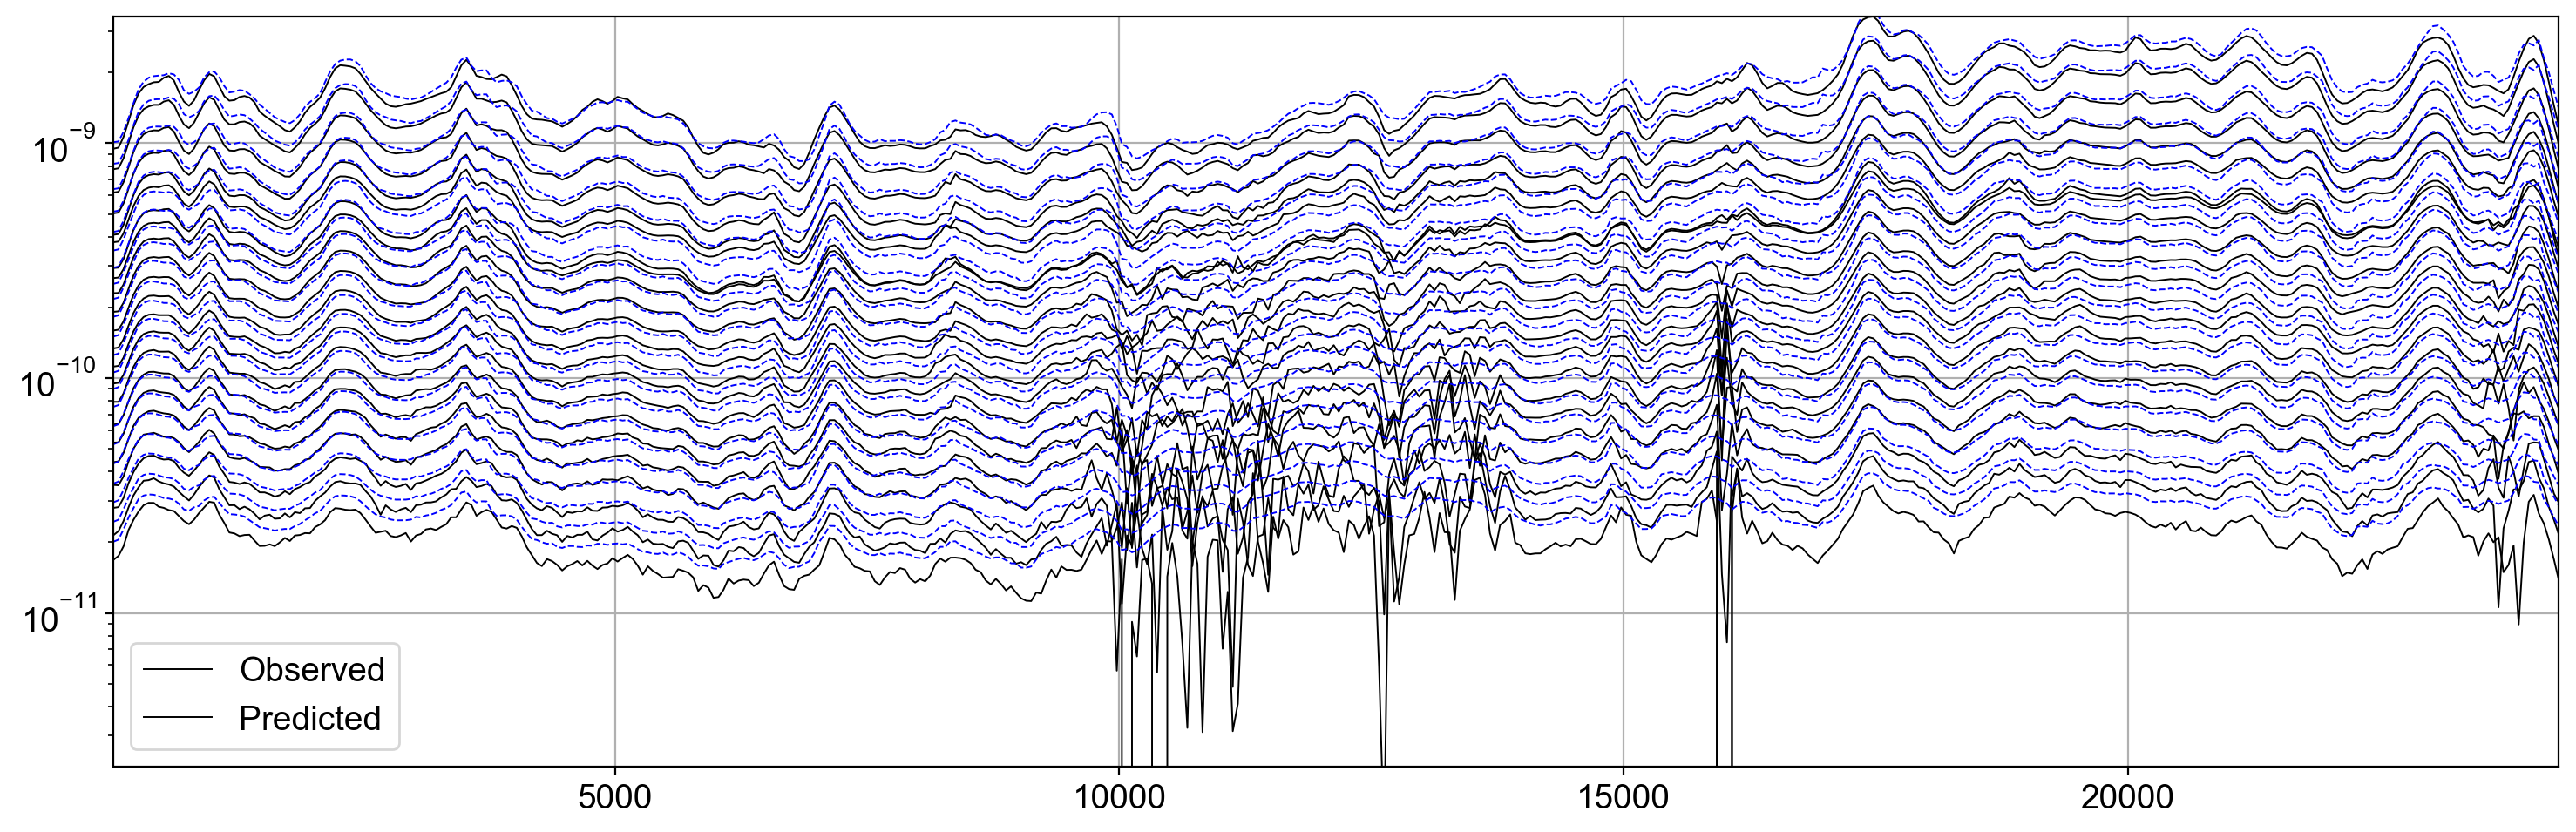

In [503]:
line = Q1.widget.kwargs['line']
df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
df_data_binned_pred_line = df_data_binned_pred[df_data_binned_pred['Line']==line]
fig, ax = plt.subplots(1,1, figsize = (15,5))
ax.semilogy(df_data_binned_line['distance'], -df_data_binned_line[dheader], 'k-', lw=0.7)
ax.semilogy(df_data_binned_pred_line['distance'], df_data_binned_pred_line[dheader], 'b--', lw=0.7)
ax.set_ylim([5e-13,1e-8])
# ax.axvline(2.61e3, c='magenta', lw = 3) # Infra 01
# ax.axvline(8.4e3, c='magenta', lw = 3) # Altitude dramatically decreasing
# ax.axvline(24.68e3, c='magenta', lw = 3) # Infra 02
# ax.axvline(26.5e3, c='magenta', lw = 3) # Power line (Intersection with road)
# ax.axvline(29.4e3, c='magenta', lw = 3) # Power line (Intersection with road)
ax.set_xlim(df_data_binned_line['distance'].min(), df_data_binned_line['distance'].max())
vmax = abs(df_data_binned_line[data_header].values).max()
vmin = noise_level
ax.set_ylim(vmin, vmax)
plt.legend(['Observed', 'Predicted'])
plt.tight_layout()

In [91]:
# for line in uniqe_lines:
#     fig, axs = plt.subplots(2,1, figsize=(20, 10), constrained_layout=True)
#     ax0, ax = axs

#     df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
#     df_data_binned_pred_line = df_data_binned_pred[df_data_binned_pred['Line']==line]

#     ax0.plot(df_data_binned['x_wgs84'], df_data_binned['y_wgs84'], '.')    
#     ax0.plot(df_data_binned_line['x_wgs84'], df_data_binned_line['y_wgs84'], '.')
#     ax0.plot(df_data_binned_line['x_wgs84'].values[0], df_data_binned_line['y_wgs84'].values[0], 'o')
#     ax0.set_aspect(1)
#     scaler = MinMaxScaler(feature_range=(df_data_binned_line['bheight'].min(), df_data_binned_line['bheight'].max()))
#     plm_norm = scaler.fit_transform(df_data_binned_line['pwrline'].values.reshape([-1,1]))

#     ax_1 = ax.twinx()
#     ax.semilogy(df_data_binned_line['distance'], -df_data_binned_line[dheader], 'k-', lw=0.5)
#     ax.semilogy(df_data_binned_pred_line['distance'], df_data_binned_pred_line[dheader], 'b--', lw=0.5)
#     ax_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
#     ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['bheight'], '-', label='Flight height')
#     ax_1.legend()
#     # ax.axvline(2.61e3, c='magenta', lw = 3) # Infra 01
#     # ax.axvline(8.4e3, c='magenta', lw = 3) # Altitude dramatically decreasing
#     # ax.axvline(24.68e3, c='magenta', lw = 3) # Infra 02
#     # ax.axvline(26.5e3, c='magenta', lw = 3) # Power line (Intersection with road)
#     # ax.axvline(29.4e3, c='magenta', lw = 3) # Power line (Intersection with road)
#     ax.set_xlim(df_data_binned_line['distance'].min(), df_data_binned_line['distance'].max())
#     plt.tight_layout()

Text(0.5, 1.0, 'Flight height')

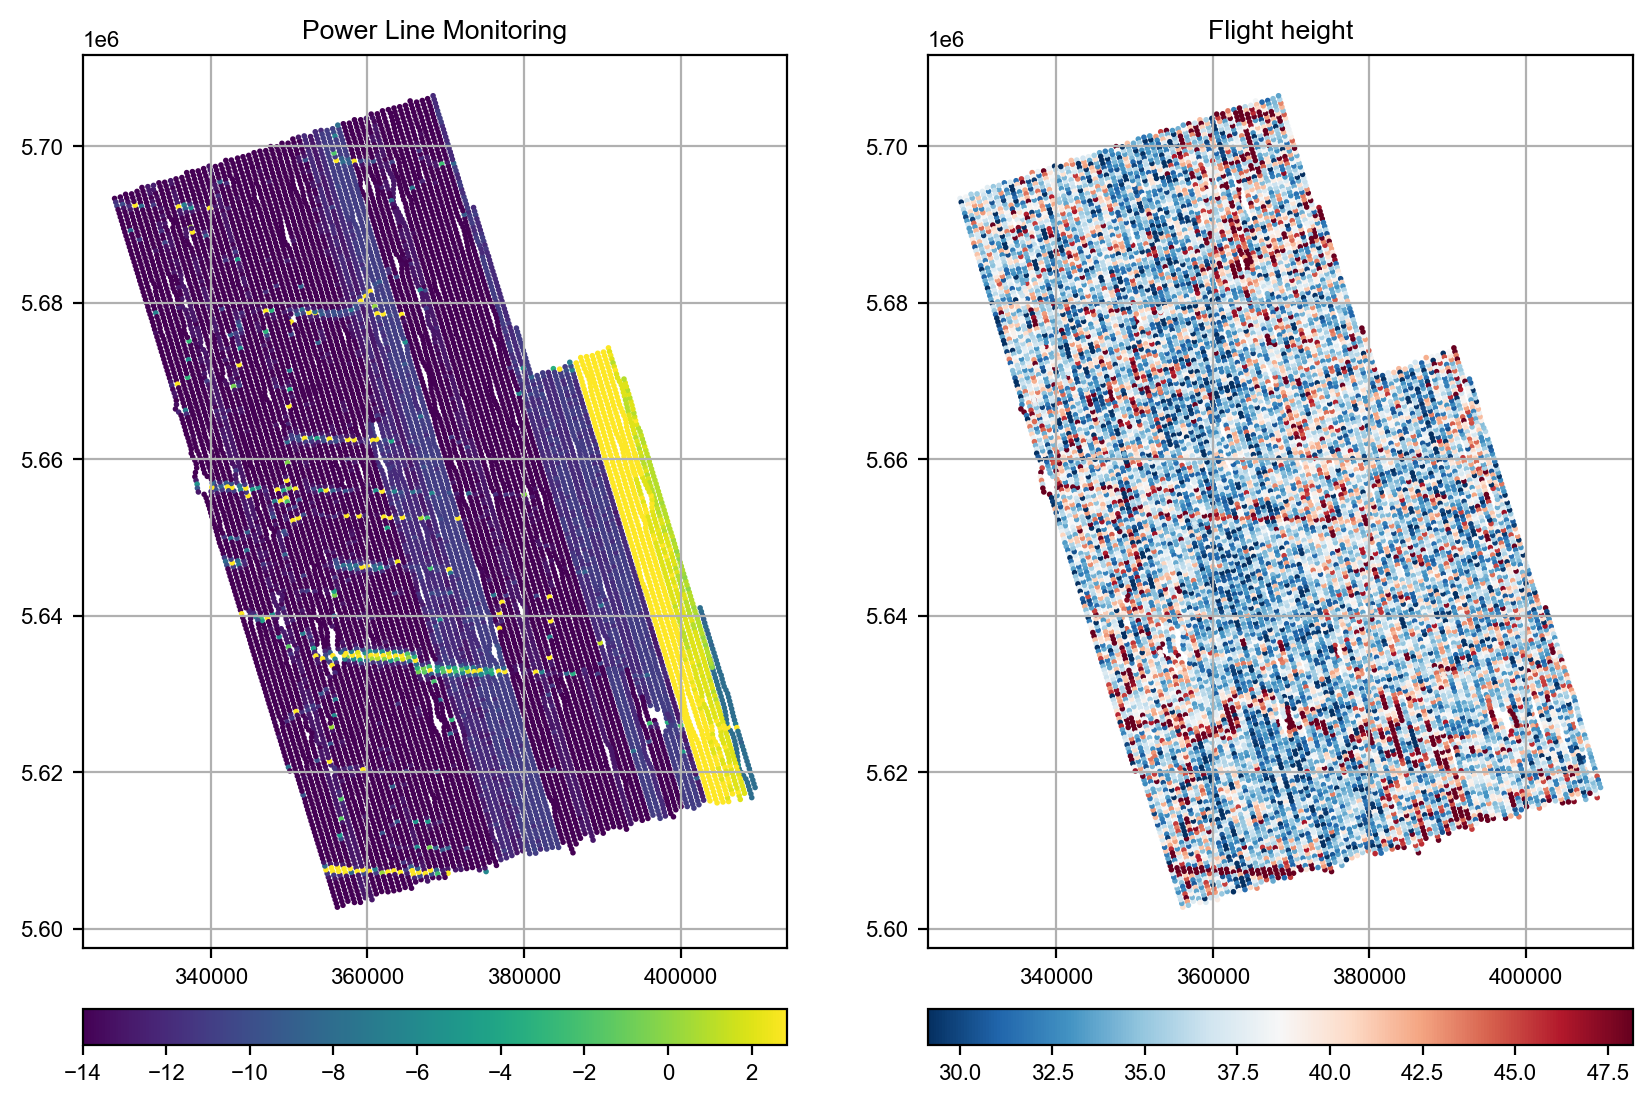

In [161]:
fig, axs = plt.subplots(1,2, figsize=(10, 8))
ax1, ax2 = axs
nskip = 10
out1 = ax1.scatter(
    df_data_binned['x_wgs84'].values[::nskip], df_data_binned['y_wgs84'].values[::nskip], c=df_data_binned['pwrline'].values[::nskip], 
    s=1,
    vmin=np.percentile(df_data_binned['pwrline'].values[::nskip], 5),
    vmax=np.percentile(df_data_binned['pwrline'].values[::nskip], 95)
)
cb1 = plt.colorbar(out1, ax=ax1, orientation='horizontal', fraction=0.05, pad=0.05)
ax1.set_aspect(1)

out2 = ax2.scatter(
    df_data_binned['x_wgs84'].values[::nskip], df_data_binned['y_wgs84'].values[::nskip], c=df_data_binned['bheight'].values[::nskip], 
    s=1,
    vmin=np.percentile(df_data_binned['bheight'].values[::nskip], 5),
    vmax=np.percentile(df_data_binned['bheight'].values[::nskip], 95),
    cmap='RdBu_r'
)
cb2 = plt.colorbar(out2, ax=ax2, orientation='horizontal', fraction=0.05, pad=0.05)
ax2.set_aspect(1)
ax1.set_title("Power Line Monitoring")
ax2.set_title("Flight height")

In [80]:
dx=100 
dy=100 
x_pad=1000 
y_pad=1000
power=0 
epsilon=None 
k_nearest_points=100

xy = inp.topography[:,:2]
xmin, xmax = xy[:,0].min()-x_pad, xy[:,0].max()+x_pad
ymin, ymax = xy[:,1].min()-y_pad, xy[:,1].max()+y_pad

nx = int((xmax-xmin) / dx)
ny = int((ymax-ymin) / dy)
hx = np.ones(nx) * dx
hy = np.ones(ny) * dy
x = np.arange(nx)*dx + xmin
y = np.arange(ny)*dy + ymin
X, Y = np.meshgrid(x, y)

tree = KDTree(xy)

d, inds_idw = tree.query(np.c_[X.flatten(), Y.flatten()], k=int(k_nearest_points))
if epsilon is None:
    epsilon = np.min([dx, dy])
w = 1.0 / ((d+epsilon) ** power)

In [92]:
i_time = 10
values = DOBS[:,i_time].astype(float)
values_idw = (np.sum(w * values[inds_idw], axis=1) / np.sum(w, axis=1))
values_idw[mask_inds] = np.nan
values_idw = values_idw.reshape(X.shape)

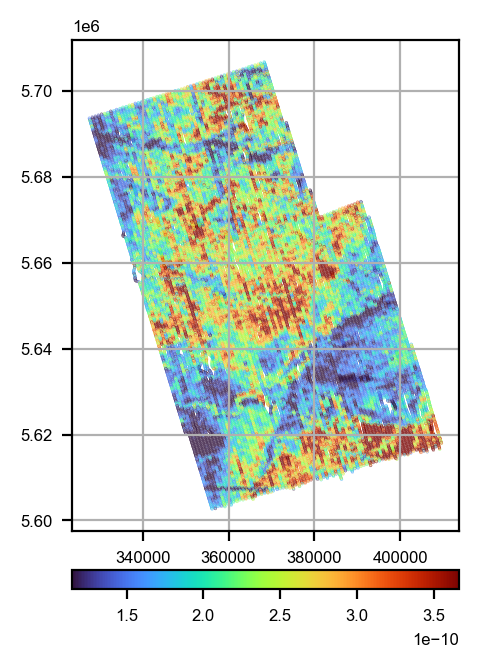

In [95]:
foo(i_time, Q1.widget.kwargs['line'])

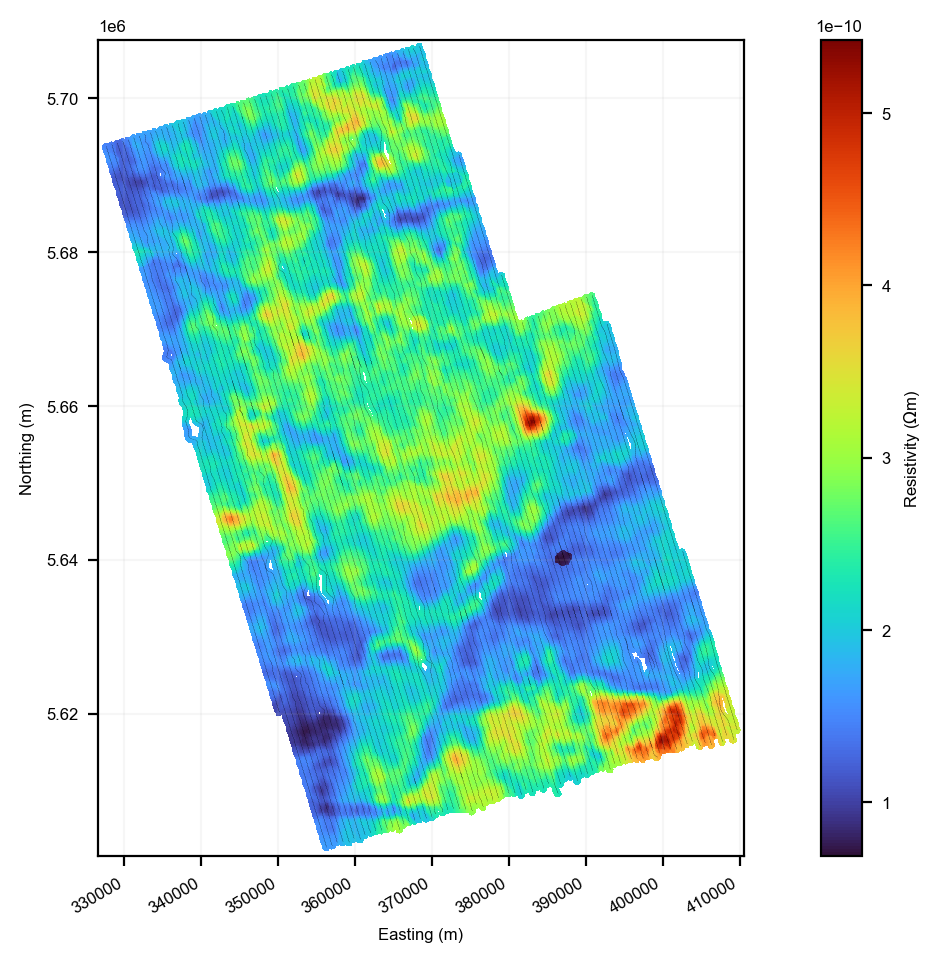

In [93]:
fig, ax = plt.subplots(1,1, figsize=(10, 6))
depth = np.cumsum(np.r_[0., hz])
out = plt.pcolormesh(x, y, -values_idw, 
    cmap='turbo', 
)
ax.plot(topography[:,0], topography[:,1], 'k,', alpha=0.1)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
cb = plt.colorbar(out)
cb.set_label('Resistivity ($\Omega$m)')
ax.grid(True, alpha=0.1)
ax.set_aspect(1)
fig.autofmt_xdate()

In [206]:
import geopandas as gpd
from shapely.geometry import LineString
# --- INPUTS ---
name = f"11-024_Alberta_{area}"
out_shp  = f"{name}_lines.geojson"
crs_epsg = 26912                 # <-- change (e.g., 4326 for lon/lat)

# --- READ ---
df = df_data_binned.copy()

# Required columns
xcol, ycol = "x_wgs84", "y_wgs84"

# Optional columns:
# - line_id: to create multiple line features
# - seq: to order points along each line
line_id_col = "Line" if "Line" in df.columns else None
seq_col     = "seq" if "seq" in df.columns else None

# --- BUILD LINES ---
lines = []
attrs = []

if line_id_col:
    grouped = df.groupby(line_id_col)
    for lid, g in grouped:
        coords = list(zip(g[xcol].to_numpy(), g[ycol].to_numpy()))
        if len(coords) < 2:
            continue
        lines.append(LineString(coords))
        attrs.append({line_id_col: lid})

# --- WRITE SHAPEFILE ---
gdf = gpd.GeoDataFrame(attrs, geometry=lines, crs=crs_epsg)
gdf_4326 = gdf.to_crs(4326)
gdf_4326.to_file(out_shp)  # writes .shp/.shx/.dbf/.prj

print(f"Wrote {len(gdf)} line(s) to {out_shp}")

Wrote 136 line(s) to 11-024_Alberta_NE_lines.geojson

## Some todos: 

- Look at the predicted data map
- 